# W05A 실습 B · 동일 데이터 비교, 튜닝, 해석과 누적 웹 앱

**딥러닝응용I(추천시스템) · 동덕여자대학교 · 유원상 교수 · 2026-2**

2026년 9월 29일 · 5주차 1차시 · 주교재 1–3장.
CPU 런타임에서 첫 셀부터 실행하세요. 파일 → Drive에 사본 저장 후 자신의 기록을 남깁니다.
설치 후 재시작 안내가 나오면 런타임을 재시작하고 첫 셀부터 다시 실행합니다.
빈칸 `None`과 빈 문자열은 연습용입니다. 뒤의 독립 시연에는 다른 변수를 사용하므로 미완성 문제를 건너뛰어도 진행할 수 있습니다.
GitHub 정의 링크와 설치 버전은 모두 `2026-fall-w05a-v2`입니다. 클래스와 함수를 열어 입력, 반환, 학습 상태를 직접 읽어 봅시다.


이번 실습은 실제 MovieLens100K를 사용합니다. 기준 모델들의 빠른 비교 → 한 요소 튜닝 → 설정 고정 → 최종 평가 → 웹 앱으로 연결합니다.
전체 사용자에 대한 제작 시 실측 참조표도 제공하지만, 학생이 지금 실행한 빠른 표본 결과와 섞지 않습니다. 네트워크 실패를 합성 데이터 성능으로 바꿔 표시하지 않습니다.


In [ ]:
import os, sys, subprocess, inspect
os.environ['GRADIO_ANALYTICS_ENABLED']='False'
IN_COLAB='google.colab' in sys.modules
COURSE_VERSION='2026-fall-w05a-v2'
if IN_COLAB:
    subprocess.run([sys.executable,'-m','pip','install','-q',
        f'luna-recommender-course[apps] @ git+https://github.com/lunalab-ai/recommender.git@{COURSE_VERSION}',
        'gradio==6.26.0'],check=True)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gradio as gr
from pathlib import Path
from dataclasses import replace
from IPython.display import display, Markdown, HTML
from luna_recsys.model_comparison import (ModelSpec,ComparisonSuite,baseline_specs,tuning_specs,
    comparison_toy,split_three,cohort,compare,select_best,pair_digest,definition_link)
from luna_recsys.ranking import FourMethodRecommender,ranking_metrics
from luna_recsys.rating_models import MeanRatingPredictor
from luna_recsys.cf_synthesis import EvidenceCF
from luna_recsys.collaborative import UserCF,binary_jaccard
print('Python',sys.version.split()[0], 'Gradio',gr.__version__, '설치 버전',COURSE_VERSION)


In [ ]:
api_objects=[ModelSpec,ComparisonSuite,ComparisonSuite.model,ComparisonSuite.recommend,
    ComparisonSuite.evaluate,baseline_specs,tuning_specs,comparison_toy,split_three,cohort,
    compare,select_best,pair_digest,ranking_metrics,MeanRatingPredictor,MeanRatingPredictor.fit,
    MeanRatingPredictor.predict_details,FourMethodRecommender,FourMethodRecommender.fit,
    FourMethodRecommender.score_catalog,EvidenceCF,EvidenceCF.fit,EvidenceCF.configured,
    EvidenceCF.predict_details,EvidenceCF.explain,UserCF,UserCF.fit,binary_jaccard,definition_link]
display(Markdown('\n'.join(f'- [{obj.__qualname__}]({definition_link(obj,COURSE_VERSION)})' for obj in api_objects)))


## 1. 원본 자료 자동 준비와 60/20/20 분할

`prepare_movielens(cache_dir, mode='real')`은 공식 자료를 내려받거나 검증된 캐시를 읽고 `PreparedMovieLens`를 반환합니다. `.data`에는 users/movies/ratings 표, `.mode`에는 실제 모드가 있습니다. 첫 실행은 파일 다운로드가 필요하고 재실행은 캐시를 사용합니다. `real` 실패는 오류를 보여 줍니다. 네트워크가 불가능하면 명시적인 `mode='synthetic'`으로 개념 연습만 할 수 있지만 이 노트북의 실데이터 비교 검증을 대신하지 않습니다.
`split_three`는 원본 행 순서를 기준으로 고정 seed 분할을 하고 train/validation/test 세 표를 반환합니다. 이 세 표는 같은 관측쌍을 공유하지 않습니다. 평균과 프로필·유사도는 train에서만 만듭니다.


In [ ]:
from luna_recsys.datasets import prepare_movielens
from luna_recsys.evaluation import split_ratings
display(Markdown(f'[prepare_movielens 정의]({definition_link(prepare_movielens,COURSE_VERSION)}) · [split_ratings 정의]({definition_link(split_ratings,COURSE_VERSION)})'))
prepared=prepare_movielens('data/local/w05a',mode='real')
data=prepared.data
train,validation,test=split_three(data.ratings)
print(prepared.mode,prepared.description)
print('train / validation / test:',len(train),len(validation),len(test))
print('사용자 / 영화:',len(data.users),len(data.movies))
suite=ComparisonSuite(train,data.users,data.movies)
ranking_users=cohort(validation,100)
print('고정 순위 표본:',len(ranking_users),'명; 평점 지표는 validation 전체')


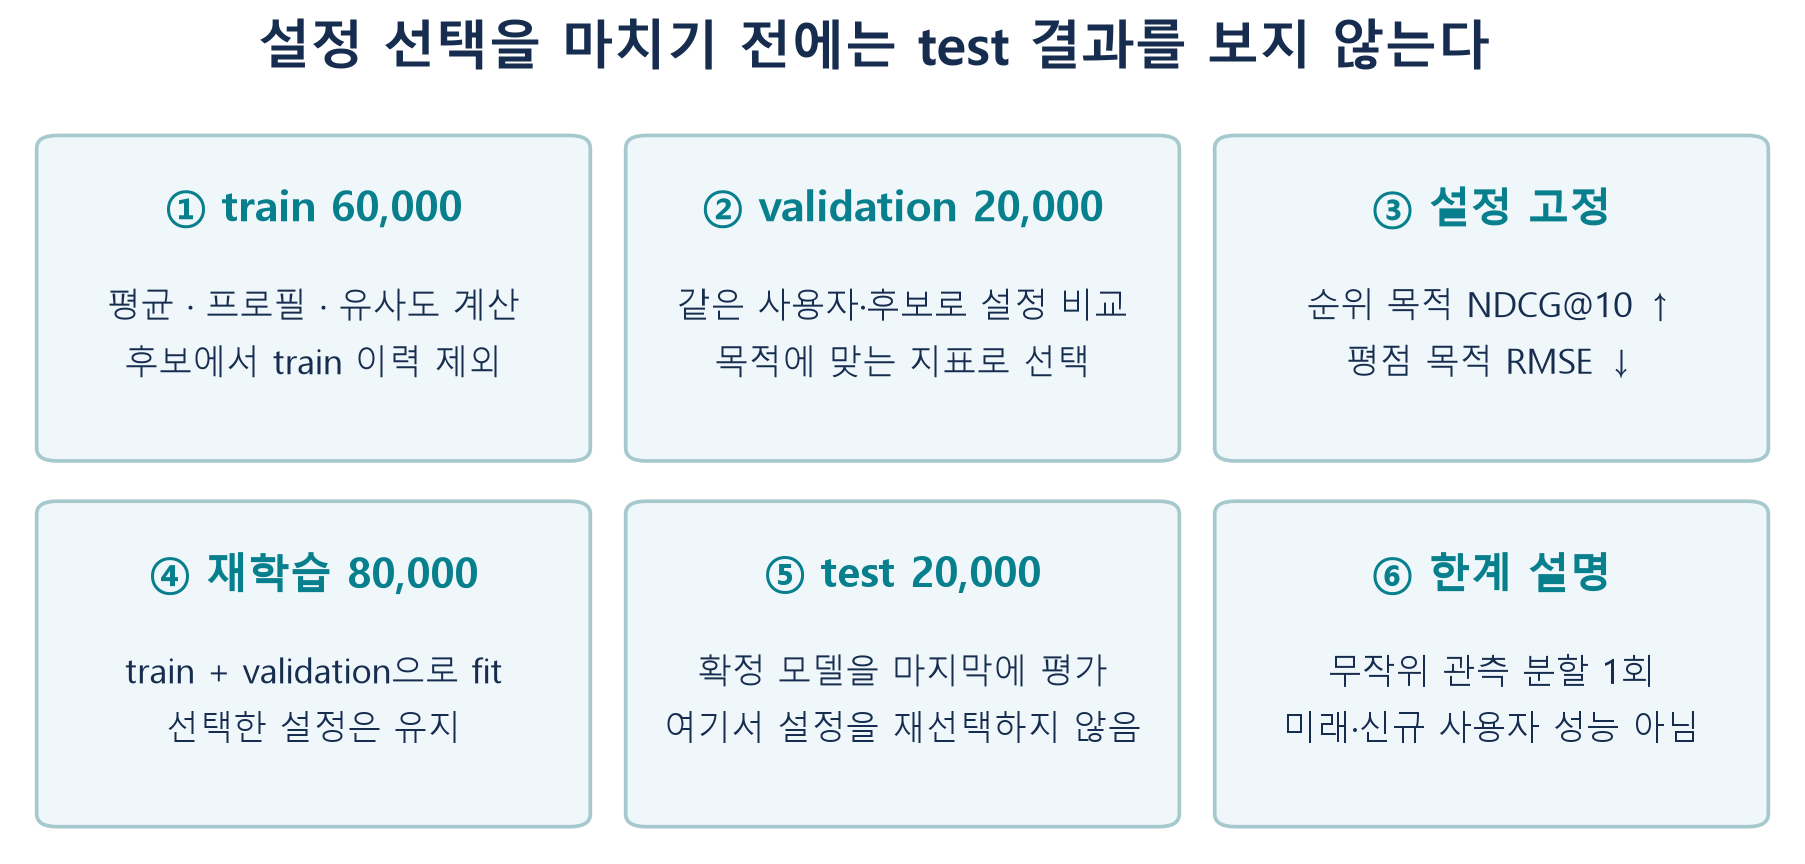


[Figure source](https://raw.githubusercontent.com/lunalab-ai/recommender/2026-fall-w05a-v2/course/notion/assets/w05a/evaluation-protocol.png)


### B1 · 디버깅: test를 연습장으로 쓴 절차

잘못된 절차는 `test에서 k=5,10,30,50을 비교 → 최고 test 결과를 최종 성능으로 보고`입니다. 자료 이름과 학습 순서를 고치세요. 자가 점검: 최종 test를 보기 전에 설정 선택이 끝나야 합니다.


In [ ]:
fixed_procedure_b1=''
print(fixed_procedure_b1 if fixed_procedure_b1 else '올바른 자료 이름과 순서를 적으세요.')


## 2. 기존 모델들을 같은 조건으로 비교하기

`baseline_specs()`는 전체/영화/집단 평균, 인기, 내용, 기본 전체 이웃 User-CF, k이웃, 평균 보정, 신뢰도 User-CF, Item-CF 및 신뢰도 조건, 이전 선택 Pearson CF의 12개 설정을 반환합니다.
`compare`의 반환은 **모델별 요약표**와 **사용자별 지표표**입니다. 평가 자료와 `ranking_users`를 한 번만 정해 모든 모델에 전달합니다. 평점은2만건 전체, 순위는고정100명 중 관련 영화가 있는 사용자만 평가합니다.
평점 단위가 아닌 count/content의 RMSE/MAE는 NaN(해당없음)이며 0으로 채우지 않습니다. 초기 계산은 CPU에서 잠시 기다려 주세요. 화면의 초수는 현재 환경에서 실측한 값입니다.


In [ ]:
specs=baseline_specs()
quick_table,quick_people=compare(suite,specs,validation,ranking_users=ranking_users)
columns=['name','rmse','mae','precision','recall','f1','ndcg','cf_support','catalog_coverage','ranking_users','excluded_no_positive','seconds']
display(quick_table[columns].round(5))
print('합계 평가 시간:',round(quick_table.seconds.sum(),1),'초')
print('모든 모델의 사용자 집합 hash 수:',quick_table.cohort_sha256.nunique())


In [ ]:
keys=[set(map(tuple,frame[['user_id','movie_id']].to_numpy())) for frame in (train,validation,test)]
assert not(keys[0]&keys[1] or keys[0]&keys[2] or keys[1]&keys[2])
assert prepared.mode=='movielens' and len(data.ratings)==100000
assert quick_table.cohort_sha256.nunique()==1 and quick_table.ranking_users.nunique()==1
assert quick_table.loc[quick_table.kind.isin(['count','content']),'rmse'].isna().all()
assert quick_table.loc[~quick_table.kind.isin(['count','content']),'rmse'].notna().all()
assert len(quick_table)==12
print('W05A_B_PROTOCOL_PASS: 실제 자료·비중복·같은 사용자·평점 단위 검증')


### B2 · k와 N 분리하기

User-CF의 이웃을5→30으로 바꾸는 실험입니다. 아래 새 설정을 만들고 추천 목록은10편으로 유지하세요. 힌트: `replace(base_spec,k=...,name=...)`. 이웃 수와 목록 길이는 서로 다른 인자입니다.


In [ ]:
base_spec_b2=ModelSpec('my-user-k5','user-k','user',k=5)
changed_spec_b2=None
my_top_n_b2=10
if changed_spec_b2 is not None:
    display(suite.recommend(changed_spec_b2,1,my_top_n_b2))


## 3. 같은 모델에서 한 설정만 바꾸기

이 시연은 평균 보정 User-CF의 k만 5/30/50으로 바꿉니다. 다른 모든 설정과 N=10은 고정합니다. 집단 최소수·내용 선호 하한·공통수·최소이웃의 전체 후보는 `tuning_specs()`에 있습니다. 수업 중에는 관심 모델 1–2개에 집중하고 목적을 먼저 적습니다.
아래 `select_best`는 같은 평가 조건인지 확인한 뒤 family별 NDCG 최대 또는 RMSE 최소 행을 고릅니다. 동점은 이름순입니다. 함수가 표의 출처를 알아서 판정하는 것은 아니므로 **validation 결과만** 전달해야 합니다.


In [ ]:
tuning_pool=[ModelSpec(f'center-k{k}','user-centered','user',k=k,centered=True) for k in (5,30,50)]
tuned,tuned_people=compare(suite,tuning_pool,validation,ranking_users=ranking_users)
display(tuned[columns].round(5))
chosen_rank=select_best(tuned,'ndcg');chosen_rating=select_best(tuned,'rmse')
print('순위 목적 선택:',chosen_rank.name.tolist())
print('평점 목적 선택:',chosen_rating.name.tolist())
ax=tuned.assign(k=[s.k for s in tuning_pool]).plot(x='k',y=['rmse','ndcg'],subplots=True,marker='o',figsize=(8,5))
plt.tight_layout();plt.show()


### B3 · 내 통제 실험

목적: 한 요소를 바꿨을 때 수치와 추천 목록이 어떻게 달라지는지 연결합니다. 집단 최소 평가 수, 내용 프로필 선호 하한, CF 공통 평가 수 중 하나를 선택하세요. 가설 → 고정 조건 → 새 설정 목록 → 비교 → 해석을 기록합니다. 힌트: `tuning_specs()`의 설정을 읽거나 `replace`로 새 설정을 만드세요. 평가 관련성 4점과 N=10은 고정합니다.


In [ ]:
hypothesis_b3=''
fixed_conditions_b3=''
my_specs_b3=[]
interpretation_b3=''
if my_specs_b3:
    my_results_b3,my_users_b3=compare(suite,my_specs_b3,validation,ranking_users=ranking_users)
    display(my_results_b3[columns])


## 4. 제작 시 전체 참조 결과를 별도로 읽기

아래 CSV는 교수자가 같은 코드로 실제로 실행한 결과입니다. 지금 계산한 100명 표본표와 전체 사용자표를 별도로 표시합니다. 원본 평점 행은 배포하지 않으며 공개 집계만 읽습니다. 파일이 없거나 연결이 실패하면 오류를 보여 주며 만든 값으로 대체하지 않습니다.
`read_csv`는 CSV를 DataFrame으로 읽습니다. [pandas 공식 API](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html).


In [ ]:
import io,urllib.request,json
def read_reference(filename):
    local=Path('data/sample/w05a-results')/filename
    if local.is_file():raw=local.read_bytes()
    else:
        url=f'https://raw.githubusercontent.com/lunalab-ai/recommender/{COURSE_VERSION}/data/sample/w05a-results/{filename}'
        with urllib.request.urlopen(url,timeout=30) as response:raw=response.read()
    return json.loads(raw) if filename.endswith('.json') else pd.read_csv(io.BytesIO(raw))
reference_full=read_reference('validation-full.csv')
reference_quick=read_reference('validation-quick.csv')
reference_protocol=read_reference('protocol.json')
display(reference_full[columns].round(5))
print('제작 시 실행:',reference_protocol['completed_at'],'전체 참조 모델 수:',len(reference_full))
print('참조 빠른 탐색 설정 수:',len(reference_quick),'분할 식별자 일치:',reference_protocol['train_pair_sha256']==pair_digest(train))
display(reference_quick.sort_values('ndcg',ascending=False)[['name','family','ndcg','rmse']].head(10))


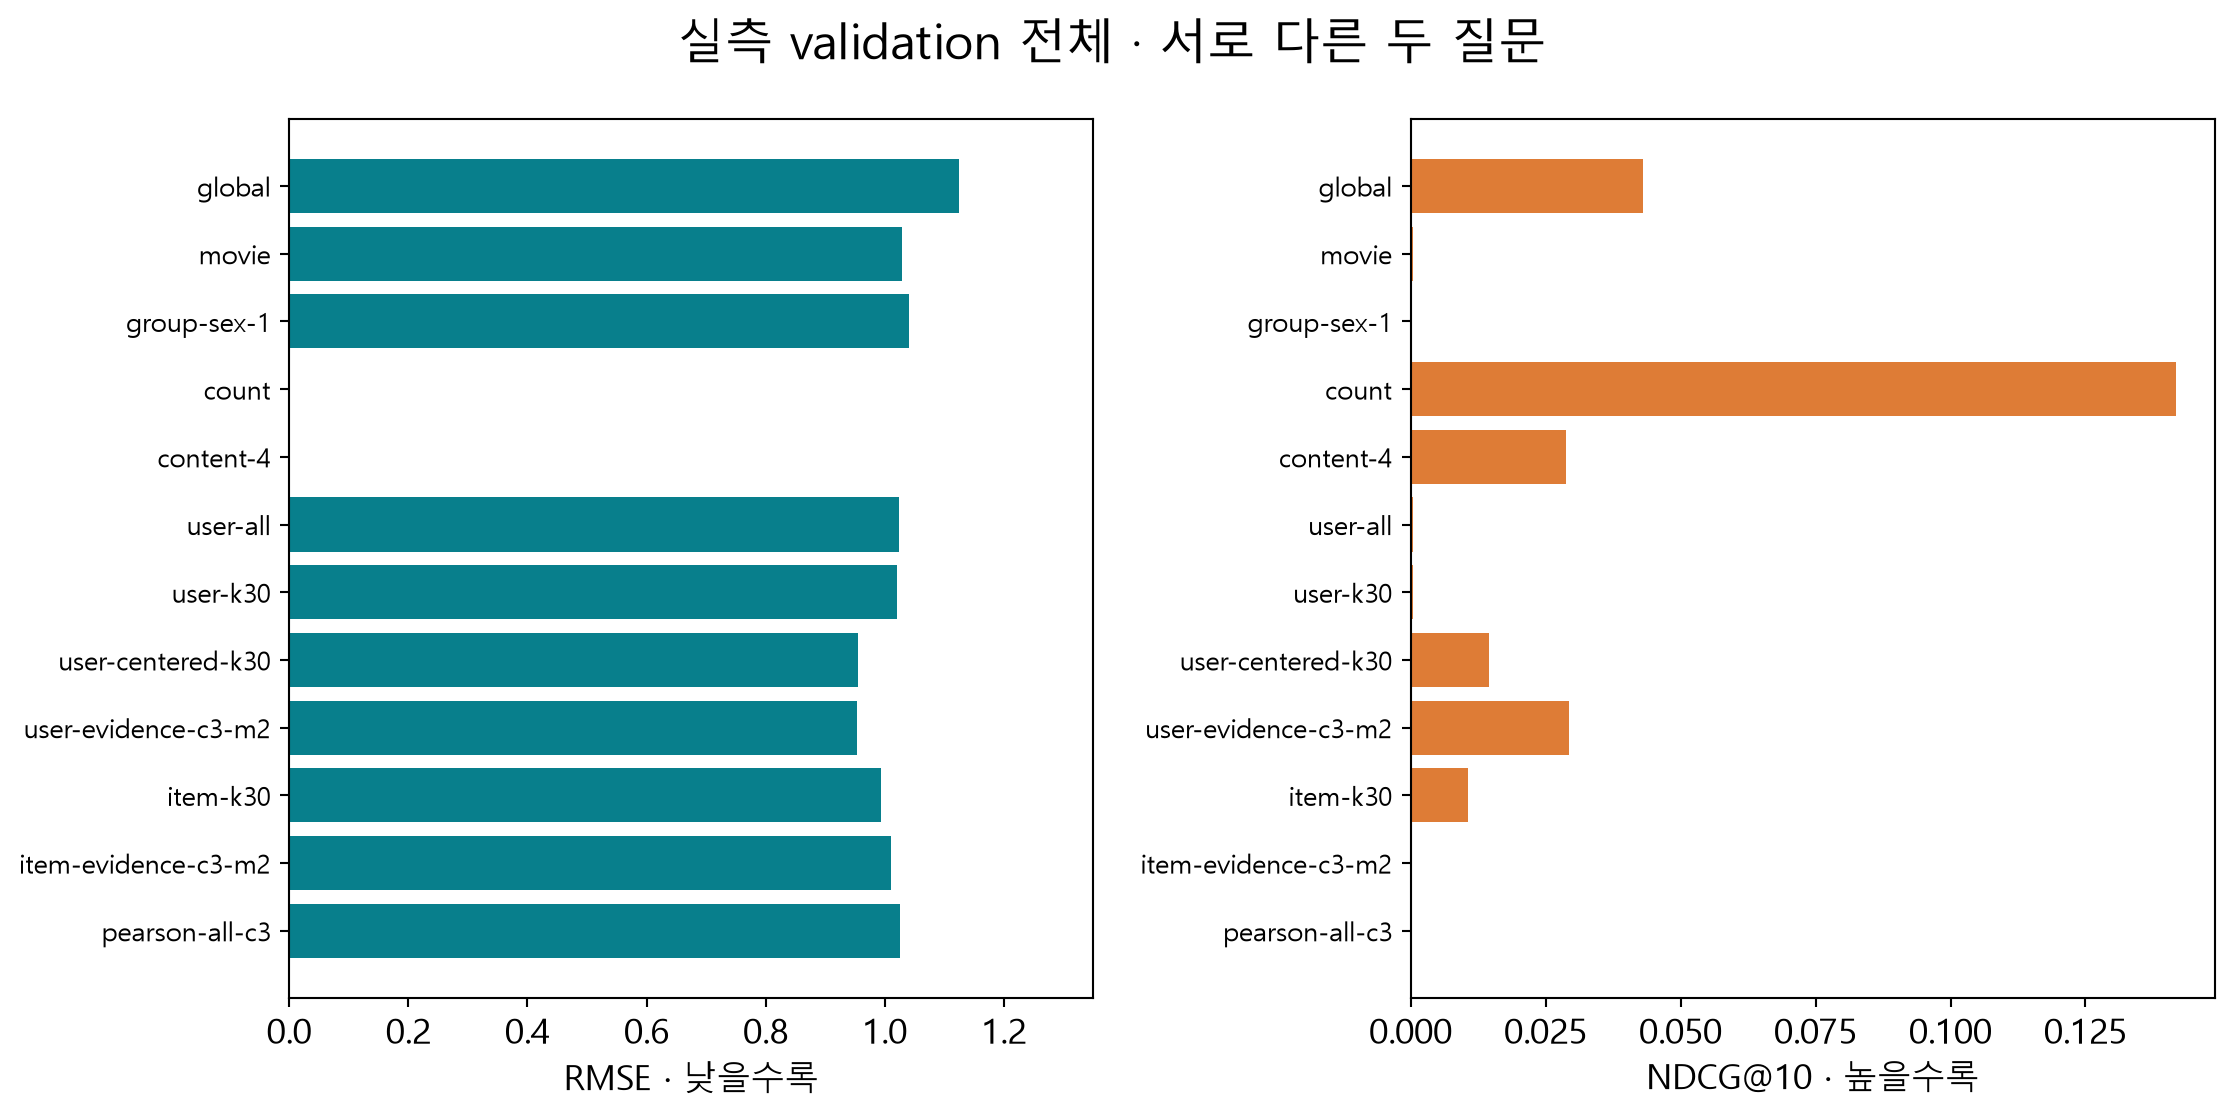


[Figure source](https://raw.githubusercontent.com/lunalab-ai/recommender/2026-fall-w05a-v2/course/notion/assets/w05a/measured-models.png)


### B4 · 정성 비교: 평균과 개인 경험

학습 평가 수가 적은 사용자와 많은 사용자를 하나씩 고르세요. 인기 추천과 평균 보정 CF의 목록을 비교하고 제목·장르·평가 수·대체 근거를 읽습니다. 힌트: `train.groupby("user_id").size()`의 양끝을 고를 수 있습니다. 자가 점검: 평균 지표 하나만으로 두 사용자 모두의 만족을 단정하지 않습니다.


In [ ]:
activity=train.groupby('user_id').size().sort_values()
selected_users_b4=[]
notes_b4=''
if selected_users_b4:
    for uid in selected_users_b4:
        display(suite.recommend(specs[3],int(uid),5))
        display(suite.recommend(specs[7],int(uid),5))


## 5. 선택을 고정한 뒤 최종 test 평가

이제 위의 3개 k 후보에서 선택한 설정을 고정합니다. 순위 목적과 평점 목적의 선택이 다르면 둘 다 평가하되, test 표를 보고 다시 고르지 않습니다. **train+validation 80,000건으로 새로 적합**하고 test 20,000건에서 평가합니다. 최종 순위 평가는 전체 평가 가능 사용자이므로 앞의 빠른 100명 표본과 직접 빼서 개선량이라고 하지 않습니다.
이 셀은 처음 실행에 시간이 걸릴 수 있습니다. 더 많은 설정을 시도할 때는 validation 단계로 돌아가며, test를 반복 보고 최적화하는 용도로 사용하지 않습니다.


In [ ]:
chosen_names=set(chosen_rank.name)|set(chosen_rating.name)
frozen_specs=[s for s in tuning_pool if s.name in chosen_names]
print('test를 보기 전 고정한 설정:',frozen_specs)
final_suite=ComparisonSuite(pd.concat([train,validation]),data.users,data.movies)
final_table,final_people=compare(final_suite,frozen_specs,test,ranking_users=None)
display(final_table[columns].round(5))
print('최종 순위 평가 집단:',final_table[['ranking_cohort','ranking_users','excluded_no_positive']].to_dict('records'))


### B5 · 결과를 세 문장으로 설명하기

내 목적, 선택 근거 지표, 개별 추천 사례 또는 한계를 각각 한 문장으로 적으세요. “RMSE가 낮아 모든 사람에게 최고” 같은 단정을 고치세요. 자가 점검: 평가 분할과 표본 범위가 포함되어야 합니다.


In [ ]:
report_b5=''
print(report_b5 if report_b5 else '목적 · 수치 근거 · 사례/한계를 적으세요.')


## 6. 누적 웹 앱의 공통 함수와 화면 연결

`ComparisonLab`은 train/validation/users/movies와 고정 순위 표본을 보관하고 같은 설정의 지표를 캐시합니다. **test는 받지 않습니다.** `comparison_view`는 두 설정·사용자·N·개인 기록을 받아 요약 HTML, 두 추천표, 지표표, 기록표, 새 기록, 그림의 7개를 반환합니다.
`build_comparison_app`은 실행 전 Gradio Blocks를 반환합니다. 이전의 기본 추천/CF/이웃/신뢰도 앱을 legacy 탭으로 연결합니다. 서버 시작은 마지막 launch에서만 수행합니다.


In [ ]:
from luna_recsys.comparison_lab import ComparisonLab,comparison_view,build_comparison_app,export_comparison
from luna_recsys.synthesis_app import CFLab,build_synthesis_app
from luna_recsys.neighborhood import NeighborCF
from luna_recsys.neighborhood_app import build_neighbor_app
from luna_recsys.cf_app import build_cf_app
for obj in [ComparisonLab,ComparisonLab.metrics,comparison_view,export_comparison,build_comparison_app,
            CFLab,CFLab.model,build_synthesis_app,NeighborCF,NeighborCF.fit,build_neighbor_app,build_cf_app]:
    display(Markdown(f'[{obj.__qualname__}]({definition_link(obj,COURSE_VERSION)})'))
lab=ComparisonLab(train,validation,data.users,data.movies,suite=suite)
# 이미 검증한 같은 설정·N의 결과만 캐시에 연결한다. 다른 설정 값을 복사하지 않는다.
for spec in specs:
    lab.cache[(spec,10)]=quick_table.loc[quick_table.name.eq(spec.name)].iloc[0].to_dict()
view=comparison_view(lab,specs[3],specs[7],1,10)
display(HTML(view[0]));display(view[3])
four=FourMethodRecommender().fit(train,data.users,data.movies)
base_app=build_cf_app(UserCF().fit(train),data.movies,comparison=four)
neighbor_app=build_neighbor_app(NeighborCF(k=30,centered=True).fit(train),data.movies,legacy=base_app)
legacy=build_synthesis_app(CFLab(train,validation,data.movies,rank_limit=100,seed=20260929),legacy=neighbor_app)
app=build_comparison_app(lab,legacy=legacy)
print('누적 웹 앱 생성:',type(app).__name__)


### B6 · 마지막 구현: 추천 표와 한 줄 해석을 함께 표시

아래 callback의 반환에 사용자의 한 줄 해석을 포함하고 버튼 이벤트를 연결하세요. 입력은 사용자와 해석문, 출력은 추천표와 Markdown입니다. 힌트: `suite.recommend(specs[3],int(uid),5)`는 인기 추천표입니다. 자가 점검: 반환 순서와 화면 출력 순서가 같아야 합니다. 완성된 누적 앱과 독립이므로 미완성이어도 다른 실험이 가능합니다.


In [ ]:
def my_callback_b6(uid,interpretation):
    top=suite.recommend(specs[3],int(uid),5)
    # 여기에 자신의 해석을 표시할 문자열을 구성하세요.
    return top,''
with gr.Blocks() as exercise_app_b:
    user_b6=gr.Number(value=1,precision=0,label='사용자 ID')
    text_b6=gr.Textbox(label='내가 관찰한 추천 이유')
    button_b6=gr.Button('추천과 해석')
    table_b6=gr.Dataframe(interactive=False);summary_b6=gr.Markdown()
    # 여기에 버튼 이벤트를 연결하세요.


In [ ]:
view2=comparison_view(lab,specs[3],specs[7],2,10,view[5])
assert len(view[5])==2 and len(view2[5])==4
assert len(view[1])==len(view[2])==10
assert set(view[1].movie_id).isdisjoint(suite.seen[1])
assert final_table.rating_count.eq(20000).all() and len(final_suite.train)==80000
assert reference_protocol['train_pair_sha256']==pair_digest(train)
assert len(reference_full)==12 and isinstance(app,gr.Blocks) and len(app.config['dependencies'])>2
print('W05A_B_RUNTIME_PASS: 실제 최종평가·참조 분할·앱 callback·누적 이벤트 검증')


### 화면에서 할 일

기준 인기와 변경 CF를 같은 사용자·N으로 비교합니다. 다음에는 설정 하나만 바꾸고 추천 제목/장르/평가 수/basis와 지표를 같이 기록합니다. 사용자 선택은 개인 목록을 바꾸며 고정 집단의 평균 지표는 유지됩니다. 비교 기록 CSV를 저장하고 자신의 해석을 붙이세요. 이전 앱 탭에서 이웃의 기여도도 확인할 수 있습니다.
공유 주소는 런타임에 의존합니다. 런타임 종료 뒤에는 다시 실행해 새 주소를 사용합니다. 로컬 검증은 launch 대신 callback과 이벤트를 검사하고 실제 브라우저 확인은 별도로 수행합니다.


In [ ]:
if IN_COLAB:
    app.launch(share=True,debug=False)
else:
    print('로컬 웹 실행: app.launch()')


## 점검 퀴즈

1. 내용 프로필의 학습 선호 하한을 바꾸면서 평가 관련성도 같이 바꾸면 무엇이 문제인가?
2. 빈 RMSE를 0으로 채우면 어떤 모델이 잘못 좋아 보이는가?
3. CF 평균 대체 관측을 오차 평가에서 제외하면 왜 비교가 달라지는가?
4. 같은 NDCG라도 표본 100명과 전체 사용자 결과를 구분해야 하는 이유는 무엇인가?
5. test를 최종 평가한 뒤 그 값을 보고 설정을 바꾸면 어떤 역할이 달라지는가?
6. 내 실험의 목적·선택 근거·한계를 한 문장씩 설명할 수 있는가?

## 핵심 정리와 참고

같은 후보·분할·사용자·관련성·N을 고정하고 모델을 비교했습니다. 지표의 단위와 분모를 읽고, 검증에서 설정을 고른 뒤 test를 마지막에 평가했습니다. 수치와 실제 추천 목록을 연결하고 기록을 CSV로 보존합니다.
[주교재와강의원문](https://github.com/lunalab-ai/recommender/blob/2026-fall-w05a-v2/course/notion/sessions/w05a-model-comparison.md) · [MovieLens](https://grouplens.org/datasets/movielens/100k/) · [검증절차](https://scikit-learn.org/stable/modules/cross_validation.html) · [순위평가](https://nlp.stanford.edu/IR-book/html/htmledition/evaluation-of-ranked-retrieval-results-1.html).
